## Visualize Mask

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [12]:
def plot_10m_wind_speed(prediction: xr.Dataset, title: str = "10m Wind Speed over Europe"):
    """
    Plots the 10m wind speed at 22:00 UTC from a prediction dataset over Europe.

    Parameters
    ----------
    prediction : xr.Dataset
        An xarray Dataset containing 10m_u_component_of_wind and 10m_v_component_of_wind variables.
    """
    # Compute 10m wind speed
    u10 = prediction["10m_u_component_of_wind"]
    v10 = prediction["10m_v_component_of_wind"]
    wind_speed = np.sqrt(u10**2 + v10**2)

    # Select time closest to 22:00 UTC on 2022-02-18
    selected_time = np.datetime64("2022-02-18T22:00")
    wind = wind_speed.sel(time=selected_time, method="nearest")

    # Plot setup
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    # ax.set_extent([-25, 45, 30, 72], crs=ccrs.PlateCarree())  # Europe extent
    ax.set_extent([-80, 30, 30, 70], crs=ccrs.PlateCarree())  # Atlantic-Europe Region

    # Plot wind speed
    wind.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=0,
        vmax=30,
        cbar_kwargs={"label": "10m wind speed (m/s)"}
    )

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.set_title(title)

    plt.show()

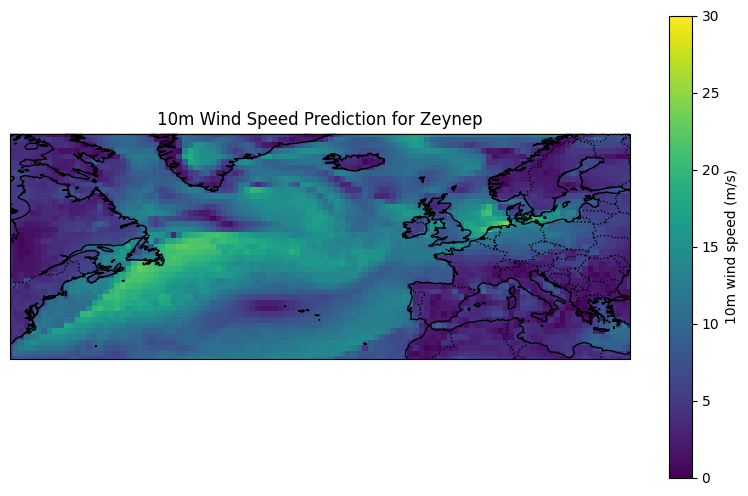

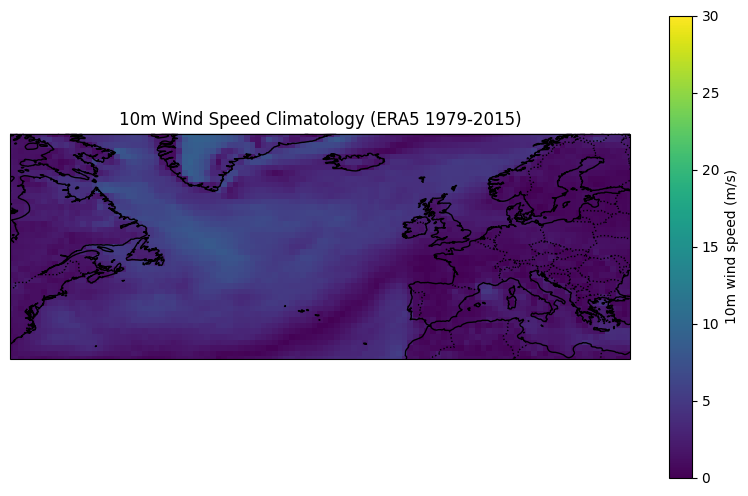

In [13]:
input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input_ds = xr.open_dataset(input_path)
climatology_ds = xr.open_dataset(climatology_path)

plot_10m_wind_speed(input_ds, title="10m Wind Speed Prediction for Zeynep")
plot_10m_wind_speed(climatology_ds, title="10m Wind Speed Climatology (ERA5 1979-2015)")